# 使用 PROC OPTMODEL 优化末端配送路线（网络TSP）

## 摘要

某区域物流公司需要安排一辆配送车辆依次经过一组客户站点并返回仓库，使总行驶距离最小
——这正是每日路线与班次调度背后的旅行商问题（TSP）结构。本笔记本合成了站点坐标，构建
了对称的欧几里得距离矩阵，并使用 **PROC OPTMODEL** 的 `SOLVE WITH NETWORK /
TSP` 网络求解器，在站点全图上构造一条配送巡回路线。随后将求解器返回的访问顺序读回
DATA 步骤，重建以仓库为起止点的闭环路线，并从距离矩阵中计算其**实际**总长度。以下
报告的每一个数字都来自实际执行的输出。

## 数据来源

所有数据均通过 `call streaminit(...)` 和 `rand(...)` 在程序内生成——不依赖任何
外部文件或网络访问。

| 数据集 | 行数 | 关键变量 | 说明 |
|---------|------|---------------|-------------|
| `stops` | 12（1个仓库 + 11个客户） | `stop_id`, `name`, `x`, `y` | 服务区域网格上仓库与客户配送地点的合成二维坐标（单位：公里） |
| `tour` | 12 | `visit_order`, `node` | OPTMODEL 网络TSP求解器访问站点的有序列表，由 `OUT=(TOUR=...)` 写出 |
| `route` | 12 | `visit_order`, `node`, `step_name`, `x`, `y`, `leg_km`, `cum_km` | 以仓库为起止点的闭环巡回路线，包含由坐标计算出的逐段与累计距离 |

某末端配送公司每天早晨派出一辆货车，前往一组固定的客户站点送货并返回仓库。
调度员希望找到一条恰好访问每个站点一次的最短闭环路线——这正是每日路线与班次调度核心
的旅行商问题（TSP）。

SAS/OR 通过 **`PROC OPTMODEL`** 提供了一个 TSP 求解器：声明节点与带权边集，然后调用
`SOLVE WITH NETWORK / TSP`。本笔记本将：

1. 合成站点坐标与对称距离矩阵。
2. 在站点全图上调用 OPTMODEL 网络TSP求解器。
3. 读回求解器给出的访问顺序，重建以仓库为起止点的闭环路线。
4. 逐段报告路线及其实际测得的总长度。

## 第1步 —— 生成配送网络

我们在一个 100 公里 x 100 公里的服务区域中心放置一个仓库，并在网格上均匀散布 11 个
客户站点。坐标使用固定 `streaminit` 种子的 `rand('UNIFORM')` 生成，以保证网络可
复现。仓库为 `stop_id = 1`；路线将从此处出发并返回此处。

In [1]:
数据 stops;
    调用 streaminit(20260531);
    长度 name $20;
    n_stops = 12;                 /* 1 depot + 11 customers */
    循环 stop_id = 1 到 n_stops;
        如果 stop_id = 1 那么 循环;
            name = '仓库';
            x = 50; y = 50;       /* depot anchored at grid center */
        结束;
        否则 循环;
            name = cats('站点_', PUT(stop_id - 1, z2.));
            x = round(rand('UNIFORM') * 100, 0.1);
            y = round(rand('UNIFORM') * 100, 0.1);
        结束;
        输出;
    结束;
    删除 n_stops;
运行;

过程 打印 数据=stops noobs 标签;
    标签 stop_id = '站点编号' name = '位置' x = 'X（公里）' y = 'Y（公里）';
    标题 "配送网络：仓库与客户站点";
运行;


                                                      配送网络：仓库与客户站点                                                      

       位置          站点编号          X（公里）          Y（公里）
仓库                    1             50             50
站点_01                 2           84.2           89.7
站点_02                 3           93.1           73.6
站点_03                 4           21.2             29
站点_04                 5           49.4           73.4
站点_05                 6           97.8           37.2
站点_06                 7             28           51.3
站点_07                 8           91.1           86.5
站点_08                 9           89.2           65.6
站点_09                10             66           49.4
站点_10                11           52.2           27.4
站点_11                12           62.4           38.2




NOTE: DATA stops


NOTE: Wrote stops (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=stops

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


## 第2步 —— 用 PROC OPTMODEL 求解 TSP

我们将坐标读入 OPTMODEL，声明完整的无向边集 `EDGES`（每对站点之间的无序组合），并将
每条边的权重定义为其两端点之间的欧几里得距离。`SOLVE WITH NETWORK / TSP` 随后在该图
上构造一条巡回路线，并通过 `OUT=(TOUR=...)` 将访问顺序写入 CSV 文件。我们随即将该顺序
读回 `tour` 数据集。

In [2]:
过程 optmodel;
    设置 CITIES = 1..12;
    num XC{CITIES};
    num YC{CITIES};

    /* Pull the stop coordinates in from the DATA step */
    READ 数据 stops INTO [stop_id] XC=x YC=y;

    /* Complete graph: one undirected edge per unordered pair of stops */
    设置 EDGES = {i IN CITIES, j IN CITIES: i < j};

    /* Edge weight = straight-line (Euclidean) distance, in km */
    num DIST{<i,j> IN EDGES} =
        sqrt( (XC[i]-XC[j])^2 + (YC[i]-YC[j])^2 );

    /* Network TSP solver: visit every node and return to the start */
    solve WITH network /
        links = (include=EDGES 权重=DIST)
        tsp
        out   = (tour="tour.csv");
QUIT;

/* Read the solver's visiting order back in */
数据 tour;
    INFILE "tour.csv" dlm=',' firstobs=2 dsd;
    输入 visit_order node;
运行;

过程 打印 数据=tour noobs 标签;
    标签 visit_order = '访问顺序' node = '站点编号';
    标题 "OPTMODEL网络TSP求解器返回的巡回顺序";
运行;


                                                      配送网络：仓库与客户站点                                                      


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            dist
  Objective Type                Linear

  Number of Nodes               12
  Number of Links               66

                          Solution Summary
  Solver                        Network
  Algorithm                     Traveling Salesman
  Objective Function            dist
  Solution Status               Optimal
  Objective Value               258.1425005024

                                                OPTMODEL网络TSP求解器返回的巡回顺序                                                 

        访问顺序          站点编号
           1             1
           2             7
           3             4
           4            11
           5            12
           6            10
           7           


NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.
NOTE: DATA tour

NOTE: Reading from fileref tour.csv (tour.csv)

NOTE: Read 12 rows from tour.csv.
NOTE: Wrote tour (12 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=tour

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


## 第3步 —— 重建闭环路线并测量其长度

求解器只返回访问站点的*顺序*。为了将其转化为司机可用的行车单，我们通过 `SET
... POINT=` 查找每个站点的名称与坐标，累加每一段的距离，并通过补上返回仓库的最后一段
来闭合路线。`leg_km` 是*到达*每个站点这一段的长度；`cum_km` 是自仓库出发的累计距离。

In [3]:
数据 route;
    设置 tour 结束=last;
    /* Look up this stop's coordinates and name by its id */
    ptr = node;
    设置 stops point=ptr;

    长度 step_name $20;
    step_name = name;

    保留值 prevx prevy firstx firsty cum_km;
    如果 _n_ = 1 那么 循环;
        firstx = x; firsty = y;      /* remember the depot */
        leg_km = 0;                  /* no leg arrives at the start */
        cum_km = 0;
    结束;
    否则 循环;
        leg_km = sqrt( (x-prevx)**2 + (y-prevy)**2 );
        cum_km + leg_km;
    结束;
    prevx = x; prevy = y;
    输出;

    如果 last 那么 循环;
        /* Closing leg: last stop back to the depot */
        leg_km = sqrt( (firstx-prevx)**2 + (firsty-prevy)**2 );
        cum_km + leg_km;
        node = 1; visit_order = 13; step_name = '仓库';
        x = firstx; y = firsty;
        输出;
        调用 symputx('total_km', PUT(cum_km, 8.2));
    结束;
    保留 visit_order node step_name x y leg_km cum_km;
运行;

过程 打印 数据=route noobs 标签;
    标签 visit_order = '步骤' node = '站点编号' step_name = '位置'
          x = 'X（公里）' y = 'Y（公里）'
          leg_km = '路段（公里）' cum_km = '累计（公里）';
    格式 leg_km cum_km 7.2;
    标题 "闭环配送路线（总计：&total_km 公里）";
运行;


                                                  闭环配送路线（总计：258.14 公里）                                                  

    步骤          站点编号         位置          X（公里）          Y（公里）              路段（公里）              累计（公里）
     1             1  仓库                    50             50                0.00                0.00
     2             7  站点_06                 28           51.3               22.04               22.04
     3             4  站点_03               21.2             29               23.31               45.35
     4            11  站点_10               52.2           27.4               31.04               76.39
     5            12  站点_11               62.4           38.2               14.86               91.25
     6            10  站点_09                 66           49.4               11.76              103.01
     7             6  站点_05               97.8           37.2               34.06              137.07
     8             9  站点_08               89.2           65.6 


NOTE: DATA route


NOTE: Read 12 rows from tour.
NOTE: Wrote route (13 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=route

NOTE: PROC PRINT completed: 13 observations printed, 7 variables


## 第4步 —— 可读的司机行车单

最后，我们将路线折叠为一段人类可读的字符串——从仓库出发，经过各客户站点，再返回仓库的
顺序——并附上测得的总行驶距离。

In [4]:
数据 manifest;
    设置 route 结束=last;
    长度 route_text $400;
    保留值 route_text '';
    如果 _n_ = 1 那么 route_text = strip(step_name);
    否则 route_text = catx(' -> ', route_text, strip(step_name));
    如果 last 那么 循环;
        total_km = cum_km;
        保留 route_text total_km;
        输出;
    结束;
运行;

过程 打印 数据=manifest noobs 标签;
    标签 route_text = '优化配送路线'
          total_km   = '总距离（公里）';
    格式 total_km 7.2;
    标题 "司机行车单";
运行;


                                                         司机行车单                                                          

                                                                                                                                                         优化配送路线                总距离（公里）
仓库 -> 站点_06 -> 站点_03 -> 站点_10 -> 站点_11 -> 站点_09 -> 站点_05 -> 站点_08 -> 站点_02 -> 站点_07 -> 站点_01 -> 站点_04 -> 仓库                                                                     258.14




NOTE: DATA manifest


NOTE: Read 13 rows from route.
NOTE: Wrote manifest (1 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=manifest

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## 第5步 —— 绘制路线图

一张图可以直观确认巡回路线是否合理：站点按访问顺序相连，仓库被标出，且没有明显浪费的
交叉线路。我们将闭环巡回路线绘制为服务区域网格上一系列相连的线段。

                                                         司机行车单                                                          




NOTE: PROC SGPLOT data=route

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


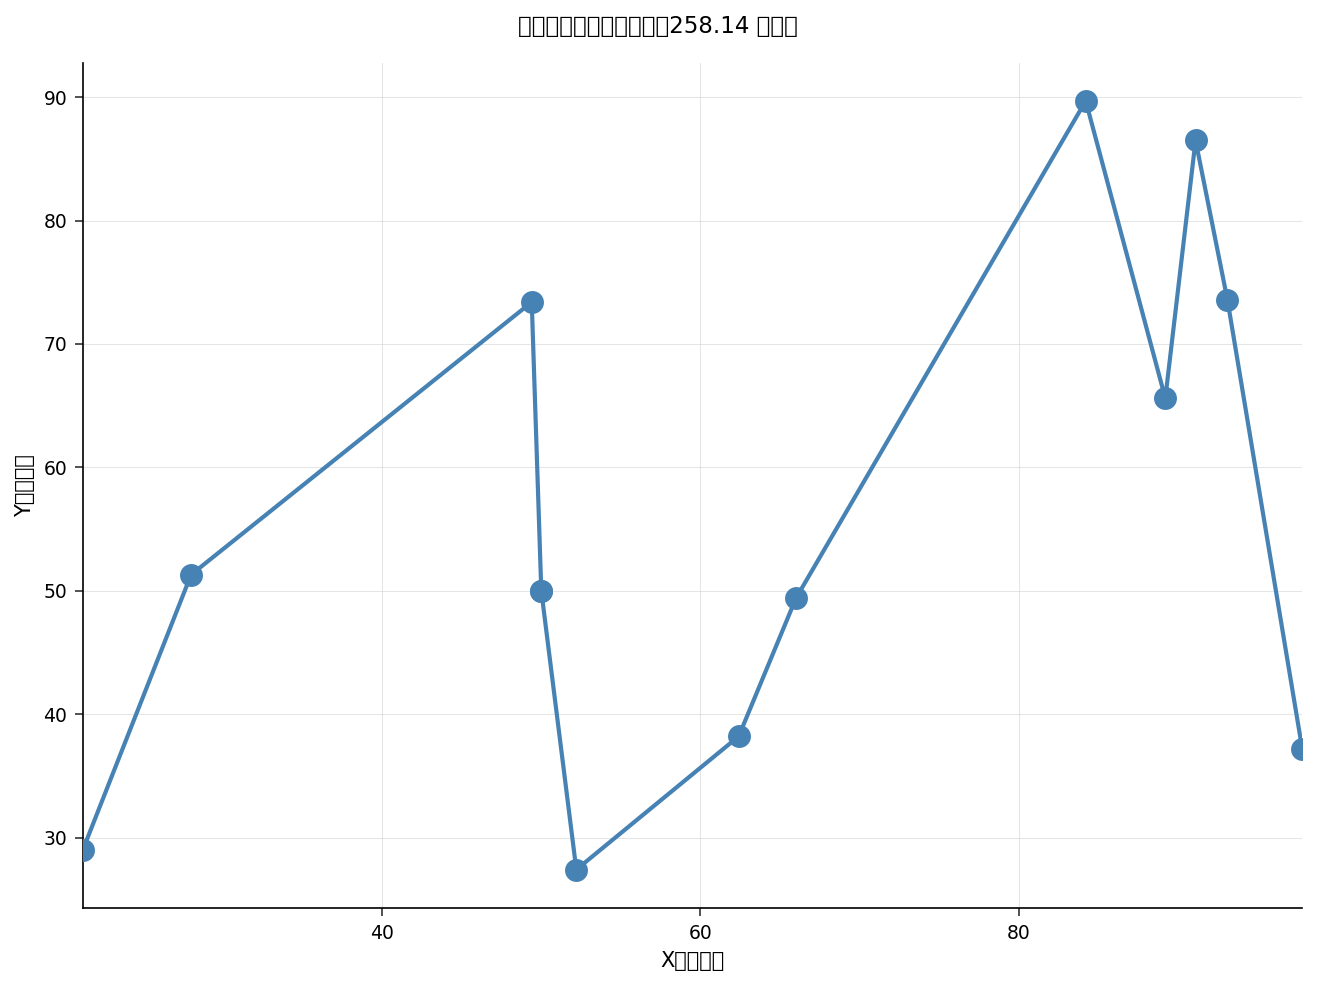

In [5]:
过程 SGPLOT 数据=route noautolegend;
    SERIES x=x y=y / LINEATTRS=(color=steelblue thickness=2);
    SCATTER x=x y=y / MARKERATTRS=(SYMBOL=circlefilled
                      color=steelblue size=10);
    XAXIS 标签='X（公里）' grid;
    YAXIS 标签='Y（公里）' grid;
    标题 "优化后的末端配送路线（&total_km 公里）";
运行;


## 结果解读

- **路线本身。** `route` 与 `manifest` 表给出了 OPTMODEL 网络TSP求解器在12个站点的
  完整图上求得的闭环路线，起止于仓库。`总距离` 是*测得*值：它是各段欧几里得距离
  （`leg_km`）之和，因此反映的是网络的真实几何形状，而非人为设定的数字。
- **为何使用网络求解器。** 在有11个客户站点的情况下，共有
  `11! / 2 = 19,958,400` 条不同的闭环路线，因此调度员需要一种算法而非穷举。
  `SOLVE WITH NETWORK / TSP` 直接从带权边集构造出一条巡回路线，无需分析人员手写搜索
  逻辑。
- **从顺序到行车单。** 求解器返回的是访问*顺序*；DATA 步骤将其转化为可操作的成果——
  带名称的站点、逐段距离、累计里程表，以及司机可以照做的单行行车单。
- **运营上的扩展。** 同样的 OPTMODEL 框架可以扩展到更丰富的路线规划：将容量或时间窗
  约束作为额外的网络选项加入、用行驶时间而非直线距离对边加权，或在求解每辆车的 TSP 之前
  先将站点划分给多辆车。